# Keyword analysis

In [1]:
import polars as pl
import polars_corpus as plc


In [9]:
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(3)

polars.config.Config

In [10]:
bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

Stefanowitsch (2020), pp. 378–380

In [13]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).select('token','target_df','LogLik').collect(engine="streaming")

In [14]:
male_keywords.head(20)

token,target_df,LogLik
str,u32,f64
"""fucking""",47,1237.921
"""er""",130,900.794
"""the""",134,574.377
""",""",133,380.467
"""yeah""",131,305.647
"""minus""",10,299.750
"""<unclear/>""",132,269.419
"""aye""",66,258.852
"""hundred""",96,249.382


<Axes: >

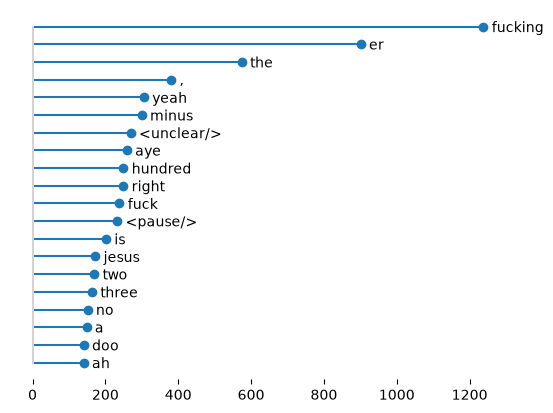

In [20]:
plc.keyword_plot(male_keywords, 'token', 'LogLik', top_k=20, descending=True)

In [19]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).select('token','target_df','LogLik').collect(engine="streaming")
female_keywords.head(20)

token,target_df,LogLik
str,u32,f64
"""she""",130,3373.992
"""her""",129,1017.036
"""said""",131,915.451
"""n't""",135,494.184
"""i""",137,369.237
"""and""",136,271.296
"""to""",135,207.086
"""cos""",129,204.473
"""christmas""",86,175.169


<Axes: >

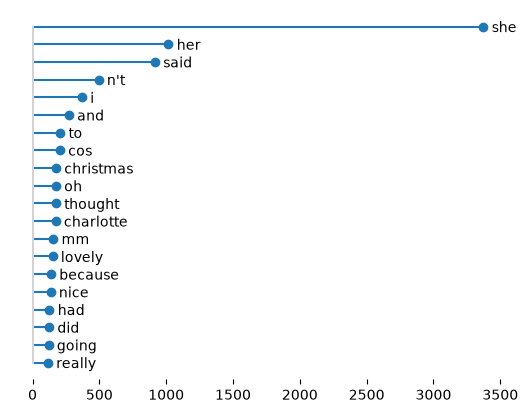

In [22]:
plc.keyword_plot(female_keywords, 'token', 'LogLik', top_k=20, descending=True)

/var/folders/02/m5hrxwkj0cxf8_1x38m20vch0000gn/T/ipykernel_67496/252336598.py:1: UserWarning: min_target_tf and min_target_df are not applied when method='ttest'
  female_keywords = plc.keywords(


<Axes: >

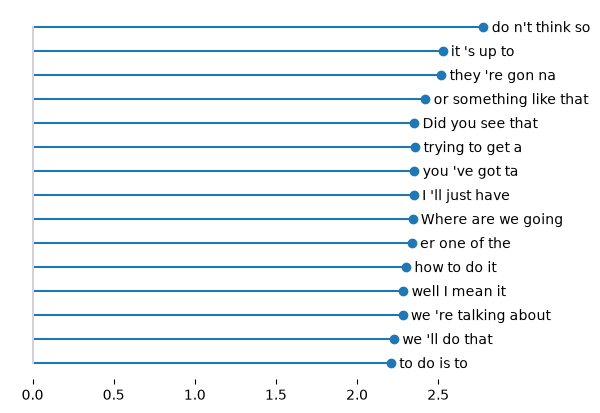

In [25]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    min_target_tf=100,
    expr=plc.ngrams(4, 'token', as_str=True)
).filter(~pl.col('token').str.contains(r"[^A-Za-z' ]")).collect(engine="streaming")

plc.keyword_plot(female_keywords, 'token', 'stat', top_k=15, descending=True)

Lijffijt et al. (2016)

In [10]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

<Axes: >

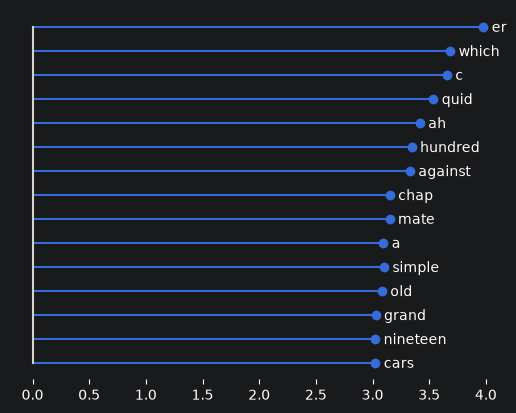

In [11]:
plc.keyword_plot(male_keywords, 'token', 'stat', top_k=15, descending=True)

In [12]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f').lazy(),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")